## 1. System Initialization
- Instantiate `ABCD_System` and allocate every register in the Steane [[7, 1, 3]] code.
- Prepare logical data blocks in $|+\rangle$ (left block of the link) and $|0\rangle$ (right block of the link), then create the ideal communication entanglement resource.
- Start from a noise-free configuration to provide a clean baseline for later experiments.

In [1]:
from ABCD import ABCD_System
import numpy as np
mysys = ABCD_System()
mysys.summary_qubit_layout()
mysys.summary_stabilizers()
mysys.summary_BSM()

Qubit layout (data):
  q_data_A       : [0 1 2 3 4 5 6]
  q_data_B_left  : [ 7  8  9 10 11 12 13]
  q_data_B_right : [14 15 16 17 18 19 20]
  q_data_C_left  : [21 22 23 24 25 26 27]
  q_data_C_right : [28 29 30 31 32 33 34]
  q_data_D       : [35 36 37 38 39 40 41]
Qubit layout (ancilla):
  q_anc_A : [42 43 44 45 46 47]
  q_anc_D : [48 49 50 51 52 53]
Qubit layout (communication):
  q_comm_A       : [54 55 56 57 58 59 60]
  q_comm_B_left  : [61 62 63 64 65 66 67]
  q_comm_B_right : [68 69 70 71 72 73 74]
  q_comm_C_left  : [75 76 77 78 79 80 81]
  q_comm_C_right : [82 83 84 85 86 87 88]
  q_comm_D       : [89 90 91 92 93 94 95]
Total unique qubits tracked: 96
S0 : +Z_Z_Z_Z_________________________________________________________________________________________
S1 : +_ZZ__ZZ_________________________________________________________________________________________
S2 : +XXX_____________________________________________________________________________________________
S3 : +___ZZZZ__________

## 2. Teleported CNOT Distribution
Run the teleportation sequence that propagates CNOT gates across adjacent data blocks (A ↔ B, B ↔ C, C ↔ D) using the prepared communication resource.

In [2]:
# mysys.initial_q_comm_noise_v1(f = 1.00)

# # # a test of adding noise to communication qubits
# # target_qubit = int(mysys.q_comm_A[5])
# # mysys._apply_single_qubit_gate('x', target_qubit, label='demo_single_qubit_gate', note='notebook example')

# Execute the teleportation routine and gather logical parity diagnostics for each link.
mysys.q_data_comm_tele_cnot(gate_missing_rate = 0.00, gate_fidelity = 1.00)


print('Results of the teleported CNOT gates:')
tableau = mysys._get_current_tableau()
support = np.concatenate((mysys.q_data_A, mysys.q_data_B_left)).astype(int)
print("-"*100)
print(f"logical XX (A, B_left) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (A, B_left) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")
support = np.concatenate((mysys.q_data_B_right, mysys.q_data_C_left)).astype(int)
print("-"*100)
print(f"logical XX (B_right, C_left) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (B_right, C_left) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")
support = np.concatenate((mysys.q_data_C_right, mysys.q_data_D)).astype(int)
print("-"*100)
print(f"logical XX (C_right, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (C_right, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")
print("-"*100)


Results of the teleported CNOT gates:
----------------------------------------------------------------------------------------------------
logical XX (A, B_left) (0 for +1, 1 for -1): 0
logical ZZ (A, B_left) (0 for +1, 1 for -1): 0
----------------------------------------------------------------------------------------------------
logical XX (B_right, C_left) (0 for +1, 1 for -1): 0
logical ZZ (B_right, C_left) (0 for +1, 1 for -1): 0
----------------------------------------------------------------------------------------------------
logical XX (C_right, D) (0 for +1, 1 for -1): 0
logical ZZ (C_right, D) (0 for +1, 1 for -1): 0
----------------------------------------------------------------------------------------------------


## 3. Local Bell-State Measurements
Execute Steane code Bell-state measurements on nodes B and C. Feed the raw syndromes into `error_correction_on_BSM_bits()` to derive two corrected classical bits per block.

In [3]:
mysys.q_data_B_local_BSM(BSM_noise = 0.00)
mysys.q_data_C_local_BSM(BSM_noise = 0.00)
mysys.error_correction_on_BSM_bits()
mysys.summary_BSM()

# Inspect the error-corrected BSM aggregates and the resulting logical parity prior to recovery.
tableau = mysys._get_current_tableau()
support = np.concatenate((mysys.q_data_A, mysys.q_data_D)).astype(int)
print("-"*100)
print('Before further operations, the logical XX and ZZ parities between A and D are:')
print()
print(f"logical XX (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")

BSM results at node B:
  z_bits_BSM_B        : [1 1 0 1 0 0 1]
  x_bits_BSM_B        : [0 1 1 1 1 0 0]
BSM results at node C:
  z_bits_BSM_C        : [1 1 0 1 0 0 1]
  x_bits_BSM_C        : [1 0 0 1 1 0 0]
Corrected BSM aggregates (B + C):
  z_bit_BSM_corrected : [0 0 0 0 0 0 0]
  x_bit_BSM_corrected : [1 1 1 0 0 0 0]
----------------------------------------------------------------------------------------------------
Before further operations, the logical XX and ZZ parities between A and D are:

logical XX (A, D) (0 for +1, 1 for -1): 0
logical ZZ (A, D) (0 for +1, 1 for -1): 1


## 4. Endpoint Syndrome Extraction and Recovery
- Measure Steane stabilizers on the end nodes (A and D) and decode the resulting syndromes.
- Apply `recovery_at_two_ends()` followed by `correct_pauli_frame()` so that the corrected Bell pair between A and D returns to $|\Phi^+\rangle$.

In [4]:
# Decode endpoint syndromes, apply the Steane recovery, and finish with Pauli-frame updates from the BSM data.
synd_X_two_ends, synd_Z_two_ends, z_error_two_ends, x_error_two_ends = mysys.syndrome_measurement_two_ends()
# print(x_error_two_ends)
# print(z_error_two_ends)
mysys.recovery_at_two_ends(gate_fidelity = 1.00, x_error_two_ends = x_error_two_ends, z_error_two_ends = z_error_two_ends)

tableau = mysys._get_current_tableau()
support = np.concatenate((mysys.q_data_A, mysys.q_data_D)).astype(int)
print("-"*100)
print('After performing QEC at both ends, the logical XX and ZZ parities between A and D are:')
print()
print(f"logical XX (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")

mysys.correct_pauli_frame()
tableau = mysys._get_current_tableau()
support = np.concatenate((mysys.q_data_A, mysys.q_data_D)).astype(int)
print("-"*100)
print('According to the information from the BSM, we restore the logical XX and ZZ parities between A and D:')
print()
print(f"logical XX (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'X'))}")
print(f"logical ZZ (A, D) (0 for +1, 1 for -1): {mysys._tableau_measure_observable(tableau, mysys._pauli_string_on_support(support, 'Z'))}")


----------------------------------------------------------------------------------------------------
After performing QEC at both ends, the logical XX and ZZ parities between A and D are:

logical XX (A, D) (0 for +1, 1 for -1): 0
logical ZZ (A, D) (0 for +1, 1 for -1): 1
----------------------------------------------------------------------------------------------------
According to the information from the BSM, we restore the logical XX and ZZ parities between A and D:

logical XX (A, D) (0 for +1, 1 for -1): 0
logical ZZ (A, D) (0 for +1, 1 for -1): 0


## 5. Sample End-to-End Run (with noise)
Demonstrate the full pipeline—including noisy primitives—to verify the logical output and expose the helper APIs used in subsequent sweeps.

In [5]:
f = 0.99
mysys_1 = ABCD_System()
mysys_1.initial_q_comm_noise_v1(f = f)
mysys_1.q_data_comm_tele_cnot(gate_missing_rate = 0.00, gate_fidelity = 1.00)
mysys_1.q_data_B_local_BSM(BSM_noise = (1-f) * 0.02)
mysys_1.q_data_C_local_BSM(BSM_noise = (1-f) * 0.015)
mysys_1.error_correction_on_BSM_bits()
synd_X_two_ends, synd_Z_two_ends, z_error_two_ends, x_error_two_ends = mysys_1.syndrome_measurement_two_ends()
mysys_1.recovery_at_two_ends(gate_fidelity = 1.00, x_error_two_ends = x_error_two_ends, z_error_two_ends = z_error_two_ends)
mysys_1.correct_pauli_frame()
logical_error, _, _ = mysys_1.check_logical_error()

print(logical_error)

False


## 6. Monte Carlo Logical-Fidelity Sweep
Run a parallel Monte Carlo study over fidelity targets $f\in[0.97,1.0]$; each point averages `n_ins` independent shots before plotting the logical fidelity curve.

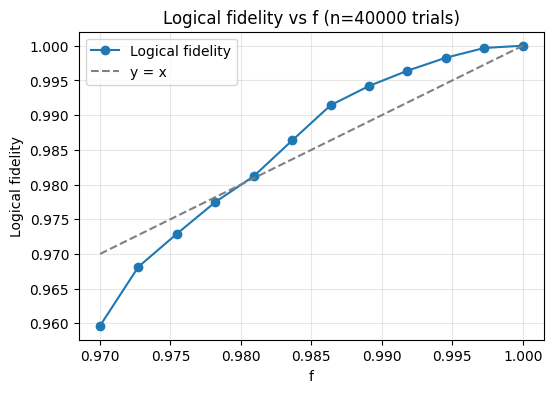

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Parallel Monte Carlo sweep: average logical fidelity across many trials for each physical fidelity value.
f_list = np.linspace(0.97, 1.0, 12)
n_ins = 40000

from concurrent.futures import ProcessPoolExecutor
import itertools
import multiprocessing as mp
import os


logical_fidelities = np.empty_like(f_list)
logical_infidelities = np.empty_like(f_list)
error_counts = np.zeros_like(f_list, dtype=np.int64)


def _run_trial(task: tuple[int, float]) -> tuple[int, int]:
    """Run one Monte Carlo sample for one fidelity point.

    Args:
        task: Tuple of sweep index and physical fidelity value.

    Returns:
        tuple[int, int]: Sweep index and logical-error bit.
    """
    f_idx, f_value = task
    system = ABCD_System()
    system.initial_q_comm_noise_v1(f=f_value)
    system.q_data_comm_tele_cnot(gate_missing_rate=0.0, gate_fidelity=1.0)
    system.q_data_B_local_BSM(BSM_noise=(1 - f_value) * 0.02)
    system.q_data_C_local_BSM(BSM_noise=(1 - f_value) * 0.015)
    system.error_correction_on_BSM_bits()
    _, _, z_error_two_ends, x_error_two_ends = system.syndrome_measurement_two_ends()
    system.recovery_at_two_ends(
        gate_fidelity=1.0,
        x_error_two_ends=x_error_two_ends,
        z_error_two_ends=z_error_two_ends,
    )
    system.correct_pauli_frame()
    logical_error, _, _ = system.check_logical_error()
    return f_idx, int(logical_error)


max_workers = max(1, os.cpu_count() or 1)
ctx = mp.get_context("fork") if hasattr(mp, "get_context") else None

# Stream all (f_idx, f_value) shots through the pool once; reduce errors as results arrive to avoid per-f scheduling overhead.
total_tasks = len(f_list) * n_ins
chunk_size = max(1, total_tasks // (max_workers * 8))  # Heuristic chunking to amortize IPC overhead.
trial_args = (
    (idx, float(f))
    for idx, f in enumerate(f_list)
    for _ in range(n_ins)
)

with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) if ctx else ProcessPoolExecutor(max_workers=max_workers) as executor:
    for f_idx, error in executor.map(_run_trial, trial_args, chunksize=chunk_size):
        error_counts[f_idx] += error

# Convert the accumulated error totals into logical infidelity/fidelity arrays for plotting.
logical_infidelities[:] = error_counts.astype(np.float64) / n_ins
logical_fidelities[:] = 1.0 - logical_infidelities

logical_fidelities = np.asarray(logical_fidelities)

summary_df = pd.DataFrame(
    {
        "f": f_list,
        "logical_fidelity": logical_fidelities,
        "logical_infidelity": logical_infidelities,
        "error_count": error_counts,
        "n_trials": n_ins,
    }
)

plt.figure(figsize=(6, 4))
plt.plot(f_list, logical_fidelities, marker="o", label="Logical fidelity")
plt.plot(f_list, f_list, linestyle="--", color="gray", label="y = x")
plt.xlabel("f")
plt.ylabel("Logical fidelity")
# plt.ylim(0.90, 1.00)
plt.title(f"Logical fidelity vs f (n={n_ins} trials)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Monte Carlo sweep summary:")
print(summary_df.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
